In [1]:
# Leemos el archivo provincias_datos_2022.csv, el cual contiene datos sobre hogares de las provincias de Argentina:

# linea 1 a 3: metadatos, información irrelevante para el análisis
# linea 4: encabezado
# linea 5 en adelante: datos

Carga y vistazo inicial del df

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# leo el dataset saltando las primeras 3 líneas
df = pd.read_csv("provicias_datos_2022.csv", skiprows=3, sep=";")

# muestro las primeras 5 filas del dataset
df.head()



,PROVINCIa,población (miles),hogares (miles),ingresos laborales (miles pesos),tasa de empleo (%),superficie (km2),exportaciones (mill usd)
0,Ciudad Autónoma de Buenos Aires,3.004,1.263,211.877.384,"4,7","205,9","311,163"
1,Buenos Aires,17.292,5.738,623.250.917,"8,7","305.907,40","33024,657"
2,Catamarca,336.000,102.000,8.460.986,"7,3","101.486,10","201,03"
3,Chaco,3.477,1.251,122.790.341,"6,5","99.763,30","516,336"
4,Chubut,967.000,287.000,24.733.558,"5,3","224.302,30","2575,372"


Info del df

In [13]:
# vemos la información del df
df.info()

# vemos los nombres de las columnas (registros)

print("Nombres de columnas: ", df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   PROVINCIa                         24 non-null     str    
 1   población (miles)                 23 non-null     float64
 2   hogares (miles)                   24 non-null     float64
 3   ingresos laborales (miles pesos)  23 non-null     str    
 4   tasa de empleo (%)                24 non-null     str    
 5   superficie (km2)                  24 non-null     str    
 6   exportaciones (mill usd)          24 non-null     str    
dtypes: float64(2), str(5)
memory usage: 1.4 KB
Nombres de columnas:  ['PROVINCIa', 'población (miles)', 'hogares (miles)', 'ingresos laborales (miles pesos)', 'tasa de empleo (%)', 'superficie (km2)', 'exportaciones (mill usd)']


In [14]:
# Primero, normalizamos los nombres de las columnas (por ejemplo, ingresos_laborales_miles_pesos)
df.columns = df.columns.str.replace(' ', '_').str.replace('(', '').str.replace(')', '').str.replace('%', 'porc').str.lower()

# seleccionamos las columnas con datos string que debemos convertir a numéricas
columnas_numericas = ['ingresos_laborales_miles_pesos','tasa_de_empleo_porc','superficie_km2', 'exportaciones_mill_usd']

# primero cambiamos los puntos por nada, y las comas por punto
for col in columnas_numericas:
    df[col] = df[col].str.replace('.', '', regex = False).str.replace(',', '.', regex = False)
    df[col] = pd.to_numeric(df[col], errors='coerce')



In [15]:
# verifico los cambios
df.info()

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   provincia                       24 non-null     str    
 1   población_miles                 23 non-null     float64
 2   hogares_miles                   24 non-null     float64
 3   ingresos_laborales_miles_pesos  23 non-null     float64
 4   tasa_de_empleo_porc             24 non-null     float64
 5   superficie_km2                  24 non-null     float64
 6   exportaciones_mill_usd          24 non-null     float64
dtypes: float64(6), str(1)
memory usage: 1.4 KB


,provincia,población_miles,hogares_miles,ingresos_laborales_miles_pesos,tasa_de_empleo_porc,superficie_km2,exportaciones_mill_usd
0,Ciudad Autónoma de Buenos Aires,3.004,1.263,211877384.0,4.7,205.9,311.163
1,Buenos Aires,17.292,5.738,623250917.0,8.7,305907.4,33024.657
2,Catamarca,336.000,102.000,8460986.0,7.3,101486.1,201.030
3,Chaco,3.477,1.251,122790341.0,6.5,99763.3,516.336
4,Chubut,967.000,287.000,24733558.0,5.3,224302.3,2575.372


In [ ]:
# calculamos ahora el total de datos faltantes
df.isnull().sum()

# verificamos que hay dos valores nulos en total, uno en la columna "población_miles", y otro en "ingresos_laborales_miles_pesos"

provincia                         0
población_miles                   1
hogares_miles                     0
ingresos_laborales_miles_pesos    1
tasa_de_empleo_porc               0
superficie_km2                    0
exportaciones_mill_usd            0
dtype: int64

In [ ]:
# verificamos qué filas son las que tienen valores faltantes
df[df.isnull().any(axis=1)]

# comprobamos que los datos faltantes se encuentran en las filas 15 y 18,
# y corresponden a las columnas ingresos_laborales_miles_pesos y población_miles respectivamente

,provincia,población_miles,hogares_miles,ingresos_laborales_miles_pesos,tasa_de_empleo_porc,superficie_km2,exportaciones_mill_usd
15,Río Negro,687.0,260.0,NaN,6.0,202168.6,460.058
18,San Luis,NaN,148.0,14056915.0,1.7,75347.1,879.344


Imputación de datos faltantes

In [18]:
# df_limpio = df.dropna() eliminaría toda aquella fila que tenga al menos un valor nulo
# en lugar de eso, imputamos los valores nulos con la mediana de cada columna

# creo el nuevo dataframe limpio
df_limpio = df.copy()

# imputamos los la población en miles de San Luis con la mediana
mediana_poblacion = df['población_miles'].median()
df_limpio.loc[df_limpio['provincia'] == 'San Luis', 'población_miles'] = mediana_poblacion

# imputamos los ingresos laborales de Río Negro con la mediana
mediana_ingresos = df['ingresos_laborales_miles_pesos'].median()
df_limpio.loc[df_limpio['provincia'] == 'Río Negro', 'ingresos_laborales_miles_pesos'] = mediana_ingresos



In [ ]:
# verificamos los datos faltantes luego de la imputación
df_limpio.isnull().sum()

# comprobamos que ahora no hay valores nulos

provincia                         0
población_miles                   0
hogares_miles                     0
ingresos_laborales_miles_pesos    0
tasa_de_empleo_porc               0
superficie_km2                    0
exportaciones_mill_usd            0
dtype: int64

Análisis exploratorio

In [20]:
# Verifico estadísticas descriptivas del dataset limpio
print("Estadísticas descriptivas:")
df_limpio.describe().round(2)

Estadísticas descriptivas:


,población_miles,hogares_miles,ingresos_laborales_miles_pesos,tasa_de_empleo_porc,superficie_km2,exportaciones_mill_usd
count,24.00,24.00,2.400000e+01,24.00,24.00,24.00
mean,308.45,199.14,6.481360e+07,10.57,152904.62,3626.67
std,311.15,145.64,1.283947e+08,21.84,176649.04,7644.73
min,1.00,1.22,8.460986e+06,1.70,205.90,40.61
25%,2.67,106.50,1.589288e+07,4.28,77659.85,424.42
50%,317.00,199.50,2.473356e+07,5.35,100624.70,1058.32
75%,596.25,295.50,3.619542e+07,6.52,157682.33,1994.46
max,967.00,535.00,6.232509e+08,110.00,910324.40,33024.66


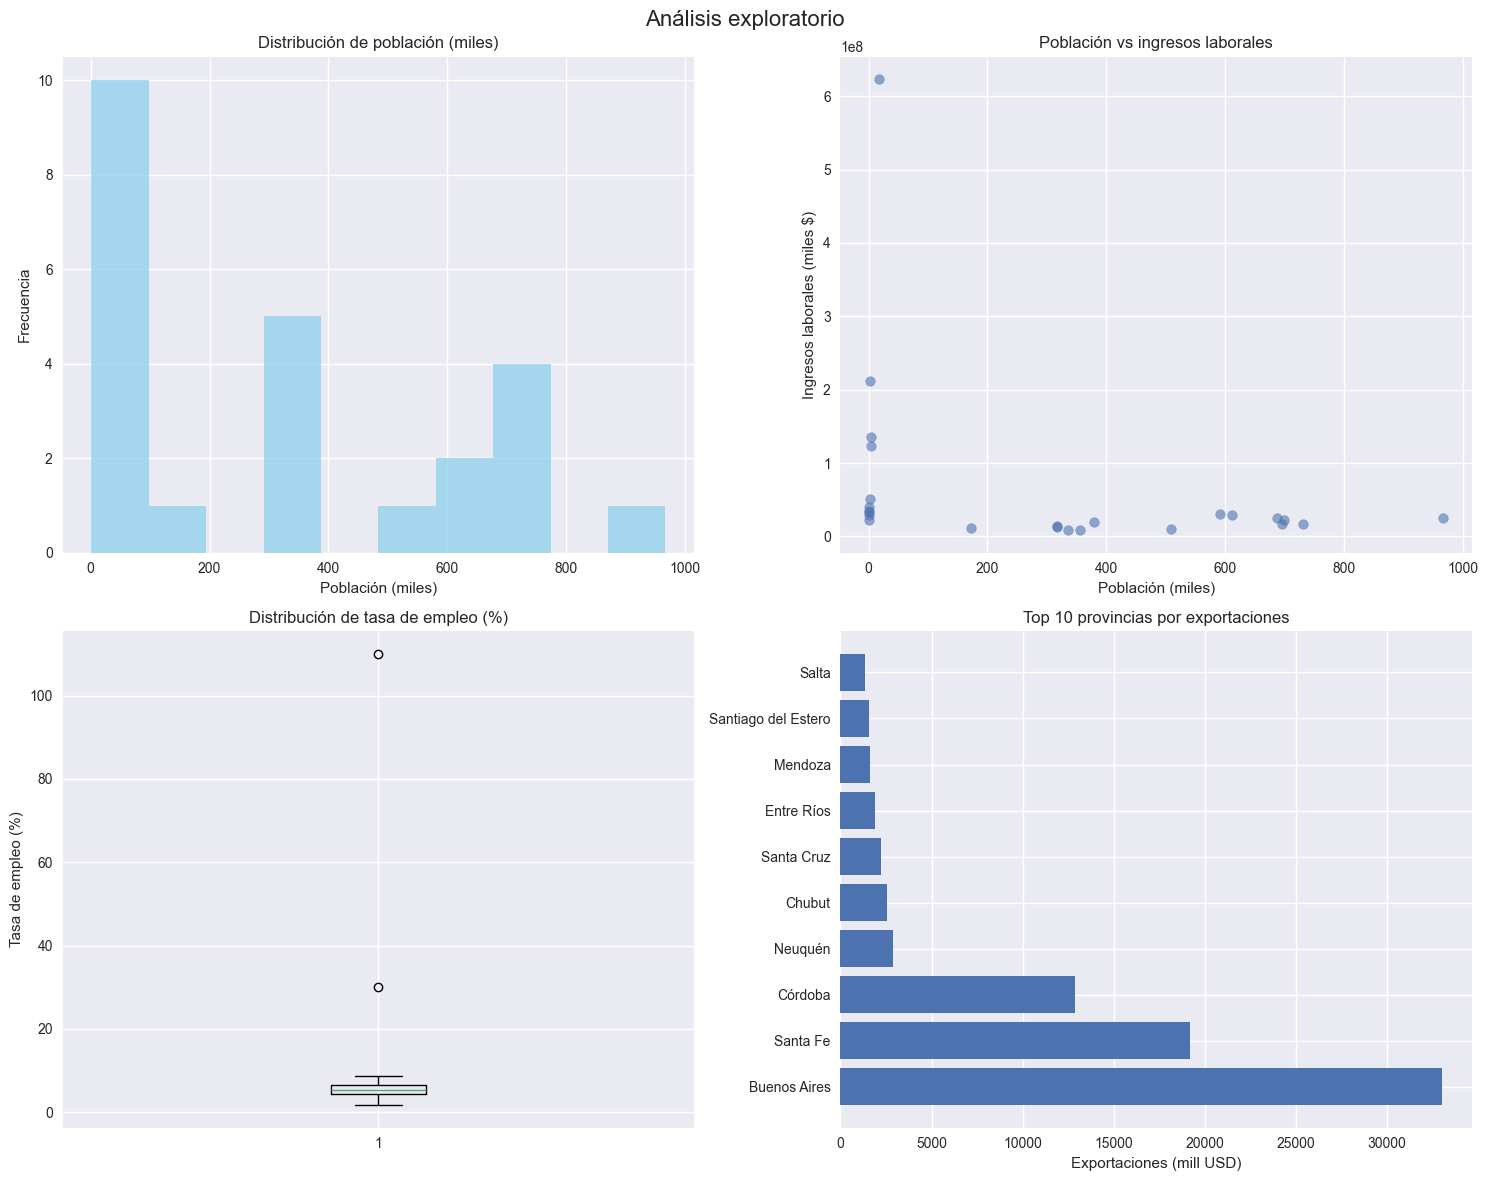

In [21]:
# Configuración para visualizaciones
plt.style.use('seaborn-v0_8') # estilo de seaborn para usar con matplotlib
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Análisis exploratorio', fontsize=16)

# 1. Histograma de población
axes[0,0].hist(df_limpio['población_miles'], bins=10, alpha=0.7, color='skyblue')
axes[0,0].set_title('Distribución de población (miles)')
axes[0,0].set_xlabel('Población (miles)')
axes[0,0].set_ylabel('Frecuencia')

# 2. Scatter plot: población vs ingresos laborales
axes[0,1].scatter(df_limpio['población_miles'], df_limpio['ingresos_laborales_miles_pesos'], alpha=0.6)
axes[0,1].set_title('Población vs ingresos laborales')
axes[0,1].set_xlabel('Población (miles)')
axes[0,1].set_ylabel('Ingresos laborales (miles $)')

# 3. Boxplot de tasa de empleo
axes[1,0].boxplot(df_limpio['tasa_de_empleo_porc'])
axes[1,0].set_title('Distribución de tasa de empleo (%)')
axes[1,0].set_ylabel('Tasa de empleo (%)')

# 4. Top 10 provincias por exportaciones
top_export = df_limpio.nlargest(10, 'exportaciones_mill_usd') # dataframe de 10 provincias con más exportaciones
axes[1,1].barh(range(len(top_export)), top_export['exportaciones_mill_usd']) # gráfico de barras horizontales
axes[1,1].set_yticks(range(len(top_export))) # cantidad de barras verticales = cantidad de filas de top_export
# len(df) devuelve el nro de filas sin contar el header

axes[1,1].set_yticklabels(top_export['provincia']) # etiquetas las barras con nombres de provincias
axes[1,1].set_title('Top 10 provincias por exportaciones') # título del gráfico
axes[1,1].set_xlabel('Exportaciones (mill USD)') # etiqueta del eje x

plt.tight_layout() # ajusta el espacio entre gráficos
plt.show()

In [ ]:
# vemos que hay outliers en el boxplot, aprox en 30% y un valor erróneo > 100% 
# (valores por encima del rango superior del boxplot)

# hay valores también en el scatterplot, provincias con poca población pero ingresos laborales altísimos

In [ ]:
# Identifico los outliers de tasa de empleo
print("Outliers en tasa de empleo:")
outliers_empleo = df_limpio[df_limpio['tasa_de_empleo_porc'] > 20]
print(outliers_empleo[['provincia', 'tasa_de_empleo_porc']]) # muestra columnas provincia y tasa de empleo porcentual

Outliers en tasa de empleo:
              provincia  tasa_de_empleo_porc
21  Santiago del Estero                 30.0
23     Tierra del Fuego                110.0


In [23]:
# Identifico los outliers de tasa de empleo ingresos laborales
print("Outliers en ingresos laborales:")
Q1 = df_limpio['ingresos_laborales_miles_pesos'].quantile(0.25) # devuelve el valor numérico tal que el 25% de los datos son menores a él
Q3 = df_limpio['ingresos_laborales_miles_pesos'].quantile(0.75) # devuelve el valor numérico tal que el 75% de los datos son menores a él
IQR = Q3 - Q1 
outliers_ingresos = df_limpio[df_limpio['ingresos_laborales_miles_pesos'] > (Q3 + 1.5 * IQR)] # valores mayores al límite superior del bigote
print(outliers_ingresos[['provincia', 'ingresos_laborales_miles_pesos']])

Outliers en ingresos laborales:
                          provincia  ingresos_laborales_miles_pesos
0   Ciudad Autónoma de Buenos Aires                     211877384.0
1                      Buenos Aires                     623250917.0
3                             Chaco                     122790341.0
20                         Santa Fe                     135661847.0
